# Phase 9: exact estimation and an empirical study of equity pair correlations

Computational record for `PHASE_9_ESTIMATION.md`.

**Structural finding (proved in-module, tested in-suite):** the
bounded-factor correlation model is *scale-observationally-
equivalent* — \((c,\mu,\sigma)\) and \((\lambda c,\mu/\lambda,
\sigma/\lambda)\) induce identical laws for every observable
correlation functional. Only the ratios \(\mu/c\) and \(\sigma/c\)
are identified from correlation observations; estimation targets
those ratios in the normalized coordinate
\(x=\rho/\sqrt{1-\rho^2}\), where increments are exactly Gaussian
and the MLE is closed-form OLS.

Empirical content: rolling 60-day realized correlations for four
liquid S&P 500 pairs from the local alpha-engine store
(2015–2026), exact MLE against two Fisher-space competitors,
out-of-sample PIT diagnostics (marginal KS **and** state-correlation,
which is where random-walk misspecification actually shows up), and
a deterministic attenuation study across estimation windows.

In [1]:
from pathlib import Path
import json, math, platform, sys, time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.stats import norm

ROOT = Path.cwd().resolve()
if not (ROOT / "phase9_estimation.py").exists():
    candidates = [ROOT, *ROOT.parents]
    ROOT = next(p for p in candidates if (p / "phase9_estimation.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import phase9_estimation as p9

SEED = 20260821
FIGURES = ROOT / "phase9_figures"
FIGURES.mkdir(exist_ok=True)
DATA_DIR = Path("/home/fire/Documents/alpha_engine/data/prices")

environment = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": scipy.__version__,
    "platform": platform.platform(),
    "seed": SEED,
}
print(json.dumps(environment, indent=2))
started = time.time()

{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "pandas": "3.0.3",
  "scipy": "1.18.0",
  "platform": "Linux-7.2.0-1-cachyos-x86_64-with-glibc2.44",
  "seed": 20260821
}


## 1. Data: realized correlation series for four liquid pairs

Daily log returns on common trading dates, 2015-01-01 onward;
rolling 60-day Pearson correlation. The series is treated as a noisy
observation of the latent bounded-factor dynamics (attenuation
quantified in Section 4).

XOM/CVX: 2860 windows, mean +0.793, sd 0.123, range [+0.338, +0.965]
JPM/BAC: 2860 windows, mean +0.847, sd 0.099, range [+0.498, +0.985]
KO/PEP: 2860 windows, mean +0.700, sd 0.120, range [+0.260, +0.947]


AAPL/MSFT: 2861 windows, mean +0.550, sd 0.223, range [-0.060, +0.953]


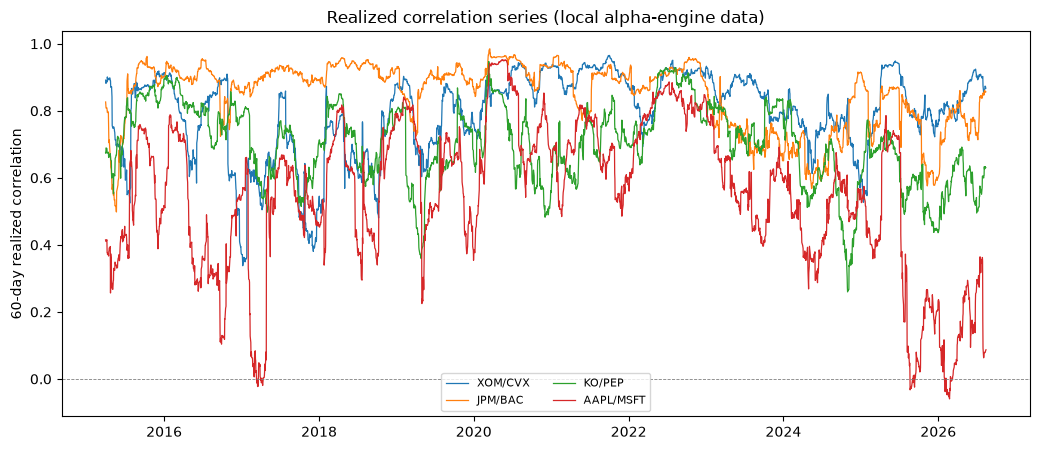

In [2]:
PAIRS = [("XOM", "CVX"), ("JPM", "BAC"), ("KO", "PEP"), ("AAPL", "MSFT")]
START = "2015-01-01"
WINDOW = 60

def load_returns(sym):
    df = pd.read_parquet(DATA_DIR / f"{sym}.parquet")
    df = df.loc[df.index >= START, "adj_close"]
    return np.log(df).diff().dropna()

series = {}
for s1, s2 in PAIRS:
    r1, r2 = load_returns(s1), load_returns(s2)
    joined = pd.concat([r1, r2], axis=1, join="inner").dropna()
    rho, ends = p9.realized_correlation_series(
        joined.iloc[:, 0].to_numpy(), joined.iloc[:, 1].to_numpy(),
        window=WINDOW)
    dates = joined.index[ends]
    series[(s1, s2)] = (rho, dates)
    print(f"{s1}/{s2}: {rho.size} windows, "
          f"mean {rho.mean():+.3f}, sd {rho.std():.3f}, "
          f"range [{rho.min():+.3f}, {rho.max():+.3f}]")

fig, ax = plt.subplots(figsize=(10.5, 4.6))
for (s1, s2), (rho, dates) in series.items():
    ax.plot(dates, rho, lw=0.9, label=f"{s1}/{s2}")
ax.axhline(0, color="gray", lw=0.6, ls="--")
ax.set_ylabel("60-day realized correlation")
ax.set_title("Realized correlation series (local alpha-engine data)")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIGURES / "phase9_rho_series.png", dpi=150)
plt.show()

## 2. Exact MLE vs Fisher-space competitors

All three models price the observed series with their own consistent
Jacobian, so likelihoods/AIC/BIC are comparable. The conjugate-RW
fit reports the identified ratios \((\mu/c,\sigma/c)\).

In [3]:
rows = []
fits_all = {}
for (s1, s2), (rho, _dates) in series.items():
    conj = p9.fit_conjugate_rw(rho)
    frw = p9.fit_fisher_rw(rho)
    fou = p9.fit_fisher_ou(rho)
    fits_all[(s1, s2)] = (conj, frw, fou)
    aic = lambda ll, k: 2 * k - 2 * ll
    rows.append({
        "pair": f"{s1}/{s2}",
        "conj mu/c": round(conj.drift, 3),
        "conj sigma/c": round(conj.volatility, 3),
        "conj logL": round(conj.log_likelihood, 1),
        "frw m": round(frw.m, 3),
        "frw s": round(frw.s, 3),
        "frw logL": round(frw.log_likelihood, 1),
        "fou kappa": round(fou.kappa, 2),
        "fou theta": round(fou.theta, 3),
        "fou s": round(fou.s, 3),
        "fou logL": round(fou.log_likelihood, 1),
        "AIC conj": round(aic(conj.log_likelihood, conj.n_params), 1),
        "AIC frw": round(aic(frw.log_likelihood, frw.n_params), 1),
        "AIC fou": round(aic(fou.log_likelihood, fou.n_params), 1),
    })
table = pd.DataFrame(rows)
print(table.to_string(index=False))

     pair  conj mu/c  conj sigma/c  conj logL  frw m  frw s  frw logL  fou kappa  fou theta  fou s  fou logL  AIC conj  AIC frw  AIC fou
  XOM/CVX     -0.020         1.169     8409.4 -0.010  0.643    8447.9       1.90      1.160  0.644    8453.3  -16814.8 -16891.7 -16900.6
  JPM/BAC      0.017         1.552     8857.8  0.009  0.639    9306.4       1.77      1.348  0.640    9311.4  -17711.6 -18608.8 -18616.9
   KO/PEP     -0.009         0.913     7396.4 -0.007  0.548    7757.9       2.29      0.909  0.549    7764.4  -14788.8 -15511.9 -15522.7
AAPL/MSFT     -0.032         0.841     6546.2 -0.031  0.621    6678.0       1.41      0.661  0.622    6681.8  -13088.3 -13352.1 -13357.6


In [4]:
# Marginal stationary sd implied by each model (comparable scale-free
# quantities): conjugate RW has no stationary law (pure diffusion);
# report instead the annualized drift/vol ratios and, for the OU,
# the stationary sd s/sqrt(2 kappa) in Fisher space.
summary = []
for (s1, s2), (conj, frw, fou) in fits_all.items():
    summary.append({
        "pair": f"{s1}/{s2}",
        "conj vol ratio (sigma/c)": round(conj.volatility, 3),
        "fisher-OU stationary sd": round(fou.s / math.sqrt(2 * fou.kappa), 3),
        "fisher-RW vol": round(frw.s, 3),
    })
print(pd.DataFrame(summary).to_string(index=False))

     pair  conj vol ratio (sigma/c)  fisher-OU stationary sd  fisher-RW vol
  XOM/CVX                     1.169                    0.331          0.643
  JPM/BAC                     1.552                    0.340          0.639
   KO/PEP                     0.913                    0.257          0.548
AAPL/MSFT                     0.841                    0.370          0.621


## 3. Out-of-sample diagnostics

Fit on the first 70% of each series; one-step-ahead PIT values on the
remaining 30%. Two complementary checks:

- **Marginal KS** — calibration of the predictive CDF;
- **PIT–state correlation** — dynamic adequacy (this is where the
  random-walk misspecification appears: its u-marginal can stay
  near-uniform while \(u_t\) correlates with the lagged state).

Also reported: out-of-sample mean log predictive density.

In [5]:
def oos_logscore_conjugate(rho, fit, dt=1/252):
    x = np.asarray(p9.conjugate_coordinate(rho, scale=1.0))
    dx = np.diff(x)
    z = (dx - fit.drift * dt) / (fit.volatility * math.sqrt(dt))
    jac = -1.5 * np.log(1.0 - rho[1:] ** 2)
    return float(np.mean(norm.logpdf(z) - math.log(fit.volatility * math.sqrt(dt)) + jac))

def oos_logscore_fisher_rw(rho, fit, dt=1/252):
    y = np.asarray(p9.fisher_coordinate(rho))
    dy = np.diff(y)
    z = (dy - fit.m * dt) / (fit.s * math.sqrt(dt))
    jac = -np.log(1.0 - rho[1:] ** 2)
    return float(np.mean(norm.logpdf(z) - math.log(fit.s * math.sqrt(dt)) + jac))

def oos_logscore_fisher_ou(rho, fit, dt=1/252):
    y = np.asarray(p9.fisher_coordinate(rho))
    decay = math.exp(-fit.kappa * dt)
    cond_sd = math.sqrt(fit.s**2 * (1 - decay**2) / (2 * fit.kappa))
    z = (y[1:] - (fit.theta + (y[:-1] - fit.theta) * decay)) / cond_sd
    jac = -np.log(1.0 - rho[1:] ** 2)
    return float(np.mean(norm.logpdf(z) - math.log(cond_sd) + jac))

diag_rows = []
pit_store = {}
for (s1, s2), (rho, _dates) in series.items():
    split = int(0.7 * rho.size)
    train, test = rho[:split], rho[split - 1:]
    conj = p9.fit_conjugate_rw(train)
    frw = p9.fit_fisher_rw(train)
    fou = p9.fit_fisher_ou(train)

    pit_c = p9.transition_pit_conjugate(test, conj)
    pit_rw = p9.transition_pit_fisher_rw(test, frw)
    pit_ou = p9.transition_pit_fisher_ou(test, fou)
    pit_store[(s1, s2)] = (pit_c, pit_rw, pit_ou)

    state = p9.fisher_coordinate(test[:-1])
    row = {"pair": f"{s1}/{s2}", "n_oos": len(pit_c)}
    for name, pit, ls in [
        ("conj", pit_c, oos_logscore_conjugate(test, conj)),
        ("frw", pit_rw, oos_logscore_fisher_rw(test, frw)),
        ("fou", pit_ou, oos_logscore_fisher_ou(test, fou)),
    ]:
        ks_stat, ks_p = p9.ks_uniformity(pit)
        _corr, z_state = p9.pit_state_correlation(pit, state)
        row[f"KS {name}"] = round(ks_stat, 3)
        row[f"KS-p {name}"] = round(ks_p, 3)
        row[f"zstate {name}"] = round(z_state, 2)
        row[f"logscore {name}"] = round(ls, 3)
    diag_rows.append(row)
diag = pd.DataFrame(diag_rows)
print(diag.to_string(index=False))

     pair  n_oos  KS conj  KS-p conj  zstate conj  logscore conj  KS frw  KS-p frw  zstate frw  logscore frw  KS fou  KS-p fou  zstate fou  logscore fou
  XOM/CVX    859    0.196        0.0        -0.98          3.027   0.193       0.0       -1.03         3.060   0.193       0.0        1.22         3.062
  JPM/BAC    859    0.268        0.0        -2.63          2.421   0.194       0.0       -2.61         2.729   0.254       0.0        0.80         2.719
   KO/PEP    859    0.221        0.0        -2.41          2.475   0.174       0.0       -2.29         2.637   0.193       0.0        0.65         2.637
AAPL/MSFT    859    0.229        0.0        -1.80          2.065   0.196       0.0       -1.90         2.173   0.217       0.0        0.52         2.172


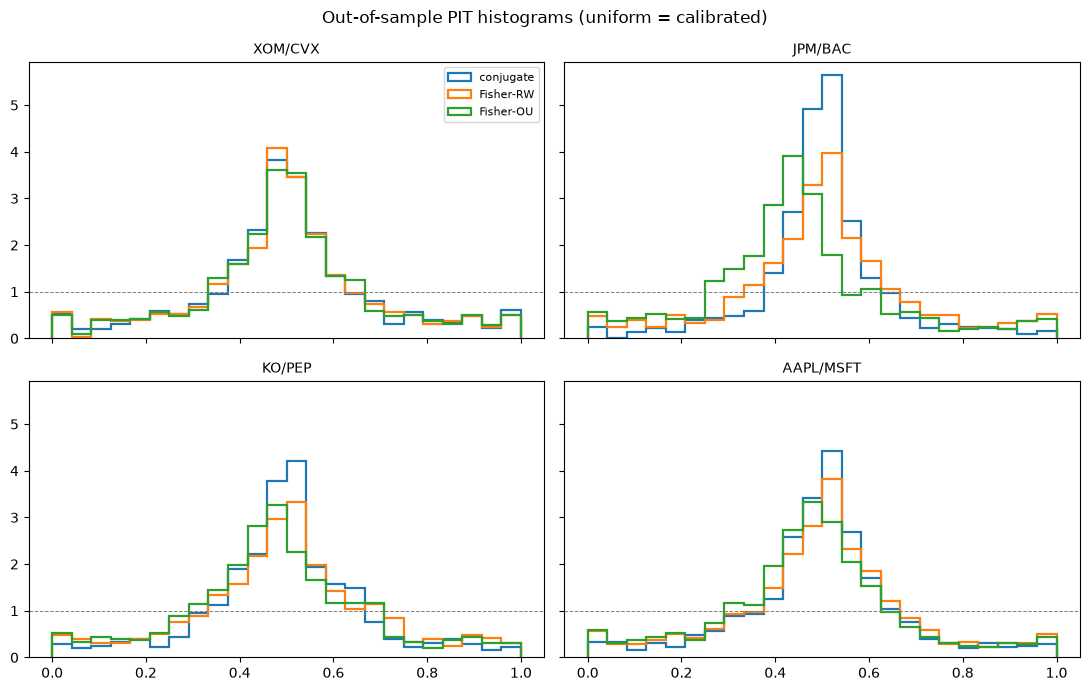

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
for ax, ((s1, s2), (pit_c, pit_rw, pit_ou)) in zip(axes.ravel(), pit_store.items()):
    for pit, label in [(pit_c, "conjugate"), (pit_rw, "Fisher-RW"), (pit_ou, "Fisher-OU")]:
        ax.hist(pit, bins=24, range=(0, 1), histtype="step", lw=1.6, label=label,
                density=True)
    ax.axhline(1.0, color="gray", lw=0.7, ls="--")
    ax.set_title(f"{s1}/{s2}", fontsize=10)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Out-of-sample PIT histograms (uniform = calibrated)")
fig.tight_layout()
fig.savefig(FIGURES / "phase9_pit_histograms.png", dpi=150)
plt.show()

## 4. Attenuation: how window noise biases the estimated dynamics

Deterministic Monte Carlo (seeded): simulate the TRUE latent system,
form rolling realized correlations at window lengths 20/40/60/120,
refit the ratios, and measure the volatility-ratio attenuation
factor (estimated / true). Window noise mechanically damps the
measured dynamics; the curve quantifies by how much.

 window  vol ratio median  true vol ratio  attenuation factor    IQR
     20            0.5644          0.4667               1.209 0.2194
     40            0.1768          0.4667               0.379 0.0715
     60            0.1180          0.4667               0.253 0.0432
    120            0.0360          0.4667               0.077 0.0145


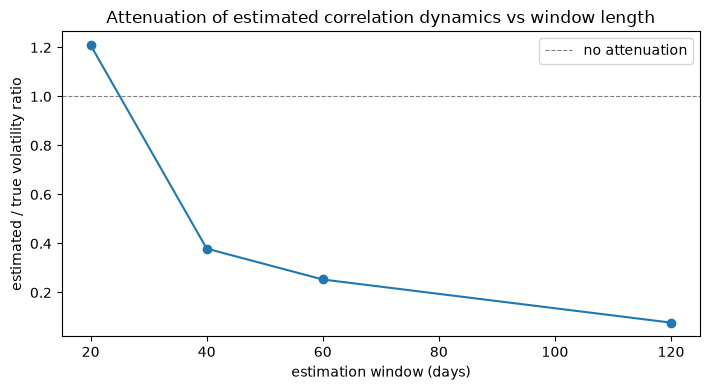

In [7]:
true_scale, true_drift, true_vol = 1.5, 0.3, 0.7
att_rows = []
for window in (20, 40, 60, 120):
    res = p9.attenuation_study(
        true_scale=true_scale, true_drift=true_drift,
        true_volatility=true_vol, n_days=2500, window=window,
        n_replications=24, seed=SEED + window)
    att_rows.append({
        "window": window,
        "vol ratio median": round(res["vol_ratio_median"], 4),
        "true vol ratio": round(res["true_vol_ratio"], 4),
        "attenuation factor": round(res["attenuation_factor"], 3),
        "IQR": round(res["vol_ratio_iqr"], 4),
    })
att = pd.DataFrame(att_rows)
print(att.to_string(index=False))

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(att["window"], att["attenuation factor"], "o-")
ax.axhline(1.0, color="gray", lw=0.8, ls="--", label="no attenuation")
ax.set_xlabel("estimation window (days)")
ax.set_ylabel("estimated / true volatility ratio")
ax.set_title("Attenuation of estimated correlation dynamics vs window length")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "phase9_attenuation.png", dpi=150)
plt.show()

## 5. Record

All estimation is exact and closed-form (OLS in the normalized
conjugate coordinate); competitors use their own consistent
Jacobians. Figures in `phase9_figures/`.

In [8]:
elapsed = time.time() - started
print(f"notebook executed in {elapsed:.1f} s")

notebook executed in 4.1 s
